In [1]:
import os
import torch
import numpy as np
from nnfabrik.builder import get_data
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [2]:
basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25, 
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [ ]:
num_neurons_per_mouse = 2000

cp = torch.load('runs/base/exp1/model_weights.pth')
features = []
for key in data_keys:
    feat = cp[f'readout.{key}._features'].cpu().squeeze().T
    idcs = np.random.choice(feat.shape[0], num_neurons_per_mouse)
    features.append(feat[idcs])
features = torch.cat(features)

In [4]:
features.shape

torch.Size([14000, 128])

In [5]:
features = (features - features.mean(axis=0)) / features.std(axis=0)

In [6]:
n = features.shape[0]
perplexity = n / 100
lr = 1
early_exaggeration = n/10

tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
features_tsne = tsne.fit_transform(features)  # Run on unnormalized data

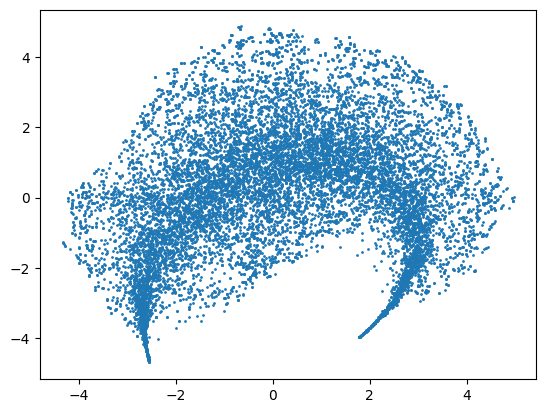

In [7]:
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], s=1)
plt.savefig('plots/tsne_lr=1_exag=N over 10.png')
plt.show()

In [8]:
n = features.shape[0]
perplexity = n / 100
lr = n / 12
early_exaggeration = 12

tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, early_exaggeration=early_exaggeration, random_state=42)
features_tsne = tsne.fit_transform(features)  # Run on unnormalized data

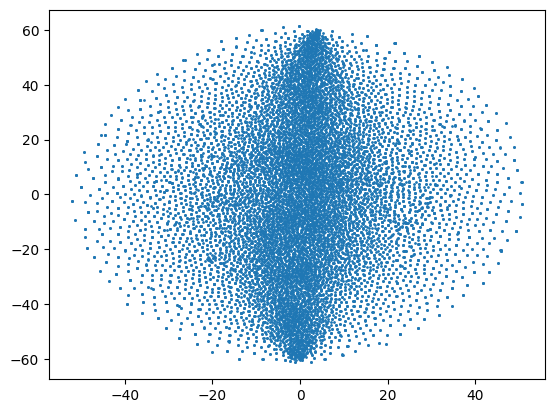

In [9]:
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], s=1)
plt.savefig('plots/tsne_lr=N over 12_eag=12')
plt.show()